# Modric V2: Tracking für das `yolo26n.pt`-Modell

### Imports

In [7]:
from pathlib import Path
import json
import csv
import math
import subprocess
from datetime import datetime

import pandas as pd
import cv2
from ultralytics import YOLO
from IPython.display import Video, display

### Neues längeres Video erzeugen

In [ ]:
SOURCE_GAME_PATH = "/data/manser/soccernet_videos/spain_laliga/2016-2017/2017-05-21 - 21-00 Malaga 0 - 2 Real Madrid/1_720p.mkv"

CLIP_START = "00:10:00"
CLIP_DURATION_SEC = 300  # 5 Minuten
CLIP_NAME = "malaga_modric_clip_10m00s_5min"

CLIP_PATH = Path(f"/data/manser/test_videos/{CLIP_NAME}.mp4")
CLIP_PATH.parent.mkdir(parents=True, exist_ok=True)

CREATE_CLIP = True

if CREATE_CLIP or not CLIP_PATH.exists():
    subprocess.run([
        "ffmpeg",
        "-y",
        "-ss", CLIP_START,
        "-i", SOURCE_GAME_PATH,
        "-t", str(CLIP_DURATION_SEC),
        "-c:v", "libx264",
        "-c:a", "aac",
        str(CLIP_PATH),
    ], check=True)

VIDEO_PATH = str(CLIP_PATH)
print(f"Clip gespeichert unter: {VIDEO_PATH}")


ffmpeg version 7.1.3-0+deb13u1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14 (Debian 14.2.0-19)
  configuration: --prefix=/usr --extra-version=0+deb13u1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-libmfx --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --enable-o

Clip gespeichert unter: /data/manser/test_videos/malaga_modric_clip_10m00s_5min.mp4


[out#0/mp4 @ 0x562282090e00] video:121249KiB audio:4869KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.175909%
frame= 7500 fps=124 q=-1.0 Lsize=  126340KiB time=00:04:59.92 bitrate=3450.8kbits/s speed=4.97x    
[libx264 @ 0x562281ff5480] frame I:51    Avg QP:21.03  size:101256
[libx264 @ 0x562281ff5480] frame P:2580  Avg QP:23.48  size: 34032
[libx264 @ 0x562281ff5480] frame B:4869  Avg QP:27.08  size:  6406
[libx264 @ 0x562281ff5480] consecutive B-frames:  5.7% 21.8%  4.8% 67.8%
[libx264 @ 0x562281ff5480] mb I  I16..4:  9.4% 66.3% 24.3%
[libx264 @ 0x562281ff5480] mb P  I16..4:  2.7%  7.7%  1.4%  P16..4: 43.7% 17.3%  9.6%  0.0%  0.0%    skip:17.6%
[libx264 @ 0x562281ff5480] mb B  I16..4:  0.2%  0.7%  0.2%  B16..8: 40.5%  5.5%  1.3%  direct: 2.2%  skip:49.3%  L0:39.6% L1:49.2% BI:11.2%
[libx264 @ 0x562281ff5480] 8x8 transform intra:65.3% inter:71.5%
[libx264 @ 0x562281ff5480] coded y,uvDC,uvAC intra: 57.6% 73.6% 32.0% inter: 17.0% 20.3% 2.4%
[libx264 @ 0x5622

### Konfiguration

In [13]:
MODEL_PATH = "/data/manser/runs/modric_v2_yolo26n/weights/best.pt"
VIDEO_PATH = "/data/manser/test_videos/malaga_modric_clip_10m00s_5min.mp4"

OUTPUT_DIR = Path("/data/manser/tracking_outputs/modric_v2_yolo26n_malaga_clip_5min_conf055")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRACKER_NAME = "botsort.yaml"
CONF_THRESHOLD = 0.55
IOU_THRESHOLD = 0.5
SAVE_VIDEO = True
FORCE_RERUN = False

CSV_PATH = OUTPUT_DIR / "tracking_results.csv"
PARQUET_PATH = OUTPUT_DIR / "tracking_results.parquet"
META_PATH = OUTPUT_DIR / "tracking_metadata.json"

AVI_PATH = OUTPUT_DIR / "tracked_video.avi"
MP4_PATH = OUTPUT_DIR / "tracked_video.mp4"

### Hilfsfunktionen

In [9]:
def safe_float(value):
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return None


def safe_int(value):
    if value is None:
        return None
    try:
        return int(value)
    except Exception:
        return None


def get_video_metadata(video_path: str) -> dict:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Video konnte nicht geöffnet werden: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_sec = frame_count / fps if fps and fps > 0 else None
    cap.release()

    return {
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration_sec": duration_sec,
    }

### Tracking rechnen und speichern

In [10]:
def run_tracking_and_save():
    model = YOLO(MODEL_PATH)
    video_meta = get_video_metadata(VIDEO_PATH)

    results = model.track(
        source=VIDEO_PATH,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        tracker=TRACKER_NAME,
        stream=True,
        persist=True,
        save=SAVE_VIDEO,
        project=str(OUTPUT_DIR),
        name="track_run",
        exist_ok=True,
    )

    rows = []

    for frame_idx, r in enumerate(results):
        boxes = r.boxes

        if boxes is None or len(boxes) == 0:
            rows.append({
                "frame_idx": frame_idx,
                "video_time_sec": frame_idx / video_meta["fps"] if video_meta["fps"] else None,
                "track_id": None,
                "class_id": None,
                "class_name": None,
                "confidence": None,
                "x1": None,
                "y1": None,
                "x2": None,
                "y2": None,
                "width": None,
                "height": None,
                "cx": None,
                "cy": None,
                "foot_x": None,
                "foot_y": None,
                "orig_w": r.orig_shape[1] if r.orig_shape else None,
                "orig_h": r.orig_shape[0] if r.orig_shape else None,
                "has_detection": 0,
            })
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy() if boxes.conf is not None else [None] * len(xyxy)
        clss = boxes.cls.cpu().numpy() if boxes.cls is not None else [None] * len(xyxy)

        if boxes.id is not None:
            ids = boxes.id.cpu().numpy()
        else:
            ids = [None] * len(xyxy)

        for box, conf, cls_id, track_id in zip(xyxy, confs, clss, ids):
            x1, y1, x2, y2 = map(float, box)
            width = x2 - x1
            height = y2 - y1
            cx = x1 + width / 2.0
            cy = y1 + height / 2.0
            foot_x = cx
            foot_y = y2

            cls_id_int = safe_int(cls_id)
            class_name = r.names.get(cls_id_int) if cls_id_int is not None else None

            rows.append({
                "frame_idx": frame_idx,
                "video_time_sec": frame_idx / video_meta["fps"] if video_meta["fps"] else None,
                "track_id": safe_int(track_id),
                "class_id": cls_id_int,
                "class_name": class_name,
                "confidence": safe_float(conf),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": width,
                "height": height,
                "cx": cx,
                "cy": cy,
                "foot_x": foot_x,
                "foot_y": foot_y,
                "orig_w": r.orig_shape[1] if r.orig_shape else None,
                "orig_h": r.orig_shape[0] if r.orig_shape else None,
                "has_detection": 1,
            })

    df = pd.DataFrame(rows)

    sort_cols = ["frame_idx"]
    if "track_id" in df.columns:
        sort_cols.append("track_id")
    df = df.sort_values(sort_cols, na_position="last").reset_index(drop=True)

    df.to_csv(CSV_PATH, index=False)

    parquet_saved = False
    parquet_error = None
    try:
        df.to_parquet(PARQUET_PATH, index=False)
        parquet_saved = True
    except Exception as e:
        parquet_error = str(e)

    metadata = {
        "created_at": datetime.now().isoformat(),
        "model_path": MODEL_PATH,
        "video_path": VIDEO_PATH,
        "tracker": TRACKER_NAME,
        "conf_threshold": CONF_THRESHOLD,
        "iou_threshold": IOU_THRESHOLD,
        "video_metadata": video_meta,
        "num_rows": int(len(df)),
        "num_detection_rows": int(df["has_detection"].sum()),
        "num_empty_frames": int((df["has_detection"] == 0).sum()),
        "unique_track_ids": sorted([
            int(x) for x in df["track_id"].dropna().unique().tolist()
        ]),
        "csv_path": str(CSV_PATH),
        "parquet_path": str(PARQUET_PATH) if parquet_saved else None,
        "parquet_saved": parquet_saved,
    }

    if not parquet_saved:
        metadata["parquet_error"] = parquet_error

    with open(META_PATH, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    track_run_dir = OUTPUT_DIR / "track_run"
    avi_candidates = list(track_run_dir.glob("*.avi"))
    if avi_candidates:
        avi_candidates[0].replace(AVI_PATH)

    return df

### Vorhandene Ergebnisse laden

In [11]:
def load_tracking_results():
    if PARQUET_PATH.exists():
        print(f"Lade Parquet: {PARQUET_PATH}")
        return pd.read_parquet(PARQUET_PATH)

    if CSV_PATH.exists():
        print(f"Lade CSV: {CSV_PATH}")
        return pd.read_csv(CSV_PATH)

    raise FileNotFoundError("Keine gespeicherten Tracking-Ergebnisse gefunden.")

### Hauptlogik

In [14]:
video_meta = get_video_metadata(VIDEO_PATH)
print(f"Video Metadata: {video_meta}")

if not FORCE_RERUN and (PARQUET_PATH.exists() or CSV_PATH.exists()):
    df = load_tracking_results()
else:
    print("Tracking wird neu berechnet ...")
    df = run_tracking_and_save()

print(df.head(10))
print(f"Anzahl Zeilen: {len(df)}")

Video Metadata: {'fps': 25.0, 'frame_count': 7500, 'width': 1280, 'height': 720, 'duration_sec': 300.0}
Lade CSV: /data/manser/tracking_outputs/modric_v2_yolo26n_malaga_clip_5min_conf055/tracking_results.csv
   frame_idx  video_time_sec  track_id  class_id class_name  confidence  x1  \
0          0            0.00       NaN       NaN        NaN         NaN NaN   
1          1            0.04       NaN       NaN        NaN         NaN NaN   
2          2            0.08       NaN       NaN        NaN         NaN NaN   
3          3            0.12       NaN       NaN        NaN         NaN NaN   
4          4            0.16       NaN       NaN        NaN         NaN NaN   
5          5            0.20       NaN       NaN        NaN         NaN NaN   
6          6            0.24       NaN       NaN        NaN         NaN NaN   
7          7            0.28       NaN       NaN        NaN         NaN NaN   
8          8            0.32       NaN       NaN        NaN         NaN NaN   
9 

### AVI zu MP4 nur wenn nötig umwandeln

In [15]:
if AVI_PATH.exists() and (FORCE_RERUN or not MP4_PATH.exists()):
    subprocess.run([
        "ffmpeg",
        "-y",
        "-i", str(AVI_PATH),
        "-c:v", "libx264",
        "-c:a", "aac",
        str(MP4_PATH),
    ], check=True)

print(f"AVI vorhanden: {AVI_PATH.exists()}")
print(f"MP4 vorhanden: {MP4_PATH.exists()}")

AVI vorhanden: True
MP4 vorhanden: True


## Analyse der Track-IDs

#### Allgemein

In [16]:
# Nur echte Detections betrachten
df_det = df[df["has_detection"] == 1].copy()

print("Anzahl aller Zeilen:", len(df))
print("Anzahl Detektions-Zeilen:", len(df_det))
print("Frames ohne Detection:", (df["has_detection"] == 0).sum())
print("Anzahl unterschiedlicher Track-IDs:", df_det["track_id"].nunique())

Anzahl aller Zeilen: 7580
Anzahl Detektions-Zeilen: 2101
Frames ohne Detection: 5479
Anzahl unterschiedlicher Track-IDs: 51


#### Wichtigste Track-IDs

In [17]:
track_counts = df_det["track_id"].value_counts().sort_values(ascending=False)
print(track_counts.head(20))

track_id
117.0    334
128.0    246
44.0     215
52.0     191
7.0      179
157.0    124
2.0      109
144.0     78
6.0       72
99.0      67
93.0      60
30.0      52
53.0      41
9.0       36
57.0      24
18.0      22
130.0     17
82.0      11
14.0      10
56.0      10
Name: count, dtype: int64


#### Track Längen pro ID

In [18]:
track_summary = (
    df_det.groupby("track_id")
    .agg(
        n_detections=("track_id", "size"),
        first_frame=("frame_idx", "min"),
        last_frame=("frame_idx", "max"),
        mean_conf=("confidence", "mean"),
        max_conf=("confidence", "max"),
    )
    .sort_values("n_detections", ascending=False)
    .reset_index()
)

track_summary.head(20)

,track_id,n_detections,first_frame,last_frame,mean_conf,max_conf
0,117.0,334,4357,4727,0.883112,0.979813
1,128.0,246,5011,5271,0.889175,0.976096
2,44.0,215,2365,2608,0.871107,0.980597
3,52.0,191,2963,3202,0.854178,0.982070
4,7.0,179,1273,1472,0.862577,0.958058
5,157.0,124,7348,7499,0.866657,0.963147
6,2.0,109,427,556,0.889392,0.978172
7,144.0,78,6677,6776,0.781506,0.919900
8,6.0,72,820,902,0.896463,0.984632
9,99.0,67,4147,4258,0.841591,0.959435


In [19]:
# Pro Frame nur die Detection mit der höchsten Confidence behalten
df_best_per_frame = (
    df_det.sort_values(["frame_idx", "confidence"], ascending=[True, False])
    .groupby("frame_idx", as_index=False)
    .first()
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

df_best_per_frame[["frame_idx", "track_id", "confidence"]].head(20)

,frame_idx,track_id,confidence
0,168,NaN,0.559744
1,426,NaN,0.812278
2,427,2.0,0.674159
3,428,2.0,0.873355
4,433,2.0,0.919749
5,434,2.0,0.919496
6,435,2.0,0.891614
7,437,2.0,0.683727
8,438,2.0,0.934658
9,439,2.0,0.950507


#### Visualisierung

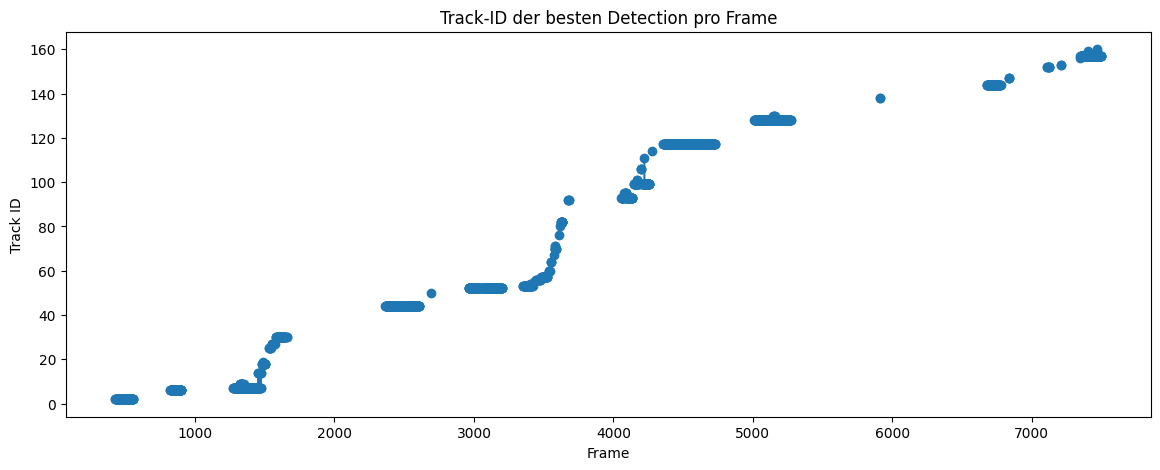

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_best_per_frame["frame_idx"], df_best_per_frame["track_id"], marker="o", linestyle="-")
plt.xlabel("Frame")
plt.ylabel("Track ID")
plt.title("Track-ID der besten Detection pro Frame")
plt.show()